#### Credit Risk Model Explainability using SHAP

We use SHAP (SHapley Additive exPlanations) to:
- Understand global drivers of default risk
- Explain individual applicant predictions
- Support transparent and interpretable decision-making

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib, shap
shap.initjs()

c:\Users\Pratik\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
model = joblib.load("C:/Users/Pratik/DS/credit-risk-ml/models/logres_baseline.joblib")
X_test, y_test = joblib.load("C:/Users/Pratik/DS/credit-risk-ml/models/test_data.joblib")

#### Preparing Data for SHAP Analysis

SHAP explanations require the same transformed feature space used by the model.
We therefore apply the trained preprocessing pipeline to the test data.

In [3]:
preprocessor = model.named_steps["preprocess"]
logreg = model.named_steps["clf"]

X_test_transformed = preprocessor.transform(X_test)

In [4]:
explainer = shap.LinearExplainer(
    logreg,   # underlying logistic model
    X_test_transformed,
    feature_perturbation="interventional"
)

shap_values = explainer.shap_values(X_test_transformed)

c:\Users\Pratik\AppData\Local\Programs\Python\Python313\Lib\site-packages\shap\explainers\_linear.py:99: FutureWarning: The feature_perturbation option is now deprecated in favor of using the appropriate masker (maskers.Independent, maskers.Partition or maskers.Impute).
  warnings.warn(wmsg, FutureWarning)


In [5]:
feature_names = preprocessor.get_feature_names_out()
feature_names

array(['num__AMT_INCOME_TOTAL', 'num__AGE_YEARS', 'num__EMPLOYED_YEARS',
       'num__EXT_SOURCE_1', 'num__EXT_SOURCE_2', 'num__EXT_SOURCE_3',
       'num__INCOME_RISK', 'num__ORG_RISK',
       'cat__NAME_CONTRACT_TYPE_Revolving loans',
       'cat__NAME_EDUCATION_TYPE_Higher education',
       'cat__NAME_EDUCATION_TYPE_Incomplete higher',
       'cat__NAME_EDUCATION_TYPE_Lower secondary',
       'cat__NAME_EDUCATION_TYPE_Secondary / secondary special',
       'cat__NAME_FAMILY_STATUS_Married',
       'cat__NAME_FAMILY_STATUS_Separated',
       'cat__NAME_FAMILY_STATUS_Single / not married',
       'cat__NAME_FAMILY_STATUS_Unknown', 'cat__NAME_FAMILY_STATUS_Widow',
       'cat__NAME_HOUSING_TYPE_House / apartment',
       'cat__NAME_HOUSING_TYPE_Municipal apartment',
       'cat__NAME_HOUSING_TYPE_Office apartment',
       'cat__NAME_HOUSING_TYPE_Rented apartment',
       'cat__NAME_HOUSING_TYPE_With parents', 'cat__CODE_GENDER_M',
       'cat__CODE_GENDER_XNA', 'cat__WEEKDAY_APPR_PROC

#### Global Feature Importance

We compute mean absolute SHAP values to identify which features most influence
model predictions across the test set.

In [6]:
shap_array = shap_values    

global_shap = pd.DataFrame({
    "feature": feature_names,
    "mean_abs_shap": np.abs(shap_array).mean(axis=0)
}).sort_values("mean_abs_shap", ascending=False)

global_shap.to_csv("C:/Users/Pratik/DS/credit-risk-ml/reports/summary_tables/top_risk_drivers.csv",index=False)

global_shap.head(15)

,feature,mean_abs_shap
35,remainder__AMT_GOODS_PRICE,0.777554
33,remainder__AMT_CREDIT,0.664255
5,num__EXT_SOURCE_3,0.363849
4,num__EXT_SOURCE_2,0.339750
7,num__ORG_RISK,0.123495
34,remainder__AMT_ANNUITY,0.116613
3,num__EXT_SOURCE_1,0.111865
143,remainder__NAME_EDUCATION_ENC,0.105261
2,num__EMPLOYED_YEARS,0.088829
134,remainder__CREDIT_INCOME_RATIO,0.058051


Key observations:
- Credit utilization dominates model decisions
- Employment stability and age follow
- Income variables are secondary but stabilizing

In [7]:
global_shap['base_feature']=(
    global_shap['feature'].str.replace(r"^(num__cat__)", "",regex=True).str.split("-").str[0]
)

global_shap_grouped = (
    global_shap.groupby("base_feature",as_index=False)["mean_abs_shap"].sum().sort_values("mean_abs_shap", ascending=False)
)

global_shap_grouped.to_csv("C:/Users/Pratik/DS/credit-risk-ml/reports/summary_tables/shap_global_grouped_.csv",index=False)

global_shap_grouped.head(10)

,base_feature,mean_abs_shap
36,remainder__AMT_GOODS_PRICE,0.777554
33,remainder__AMT_CREDIT,0.664255
28,num__EXT_SOURCE_3,0.363849
27,num__EXT_SOURCE_2,0.339750
30,num__ORG_RISK,0.123495
31,remainder__AMT_ANNUITY,0.116613
26,num__EXT_SOURCE_1,0.111865
119,remainder__NAME_EDUCATION_ENC,0.105261
25,num__EMPLOYED_YEARS,0.088829
57,remainder__CREDIT_INCOME_RATIO,0.058051



The SHAP summary plot below shows:
- Which features most strongly influence default predictions
- Whether higher feature values increase or decrease risk
- The distribution of feature effects across the population

Positive SHAP values indicate increased default risk,
while negative values indicate reduced risk.

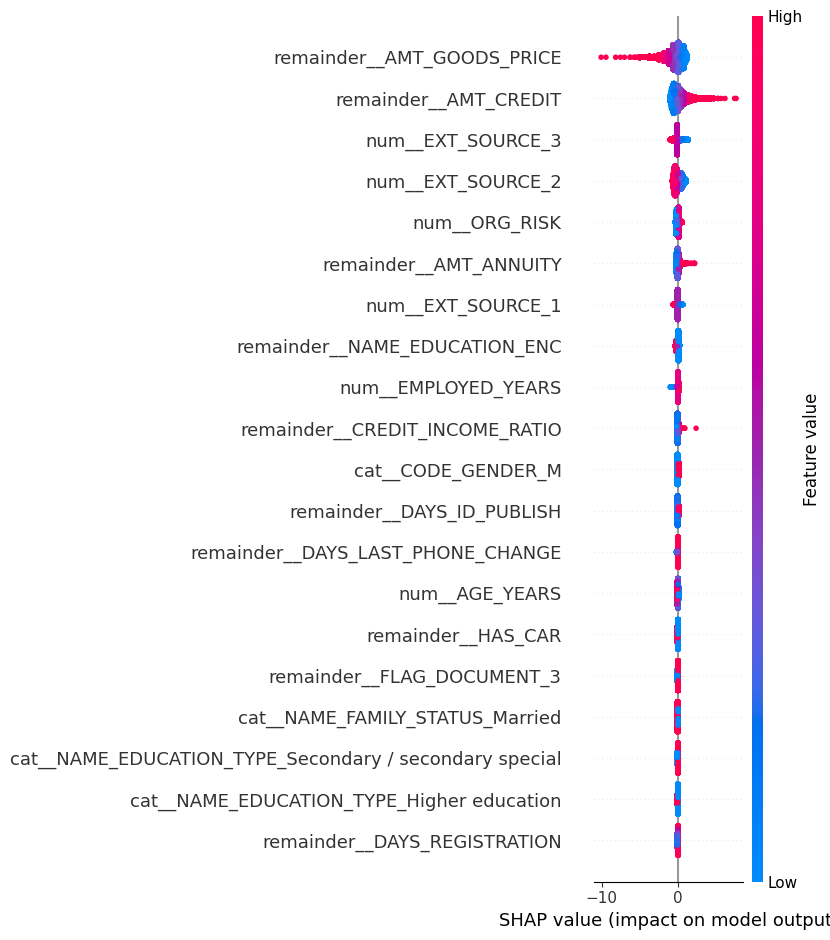

In [80]:
shap.summary_plot(shap_values, X_test_transformed, feature_names=feature_names , show=False)
plt.savefig('C:/Users/Pratik/DS/credit-risk-ml/reports/figures/summary_plt.png',dpi=300)
plt.show()

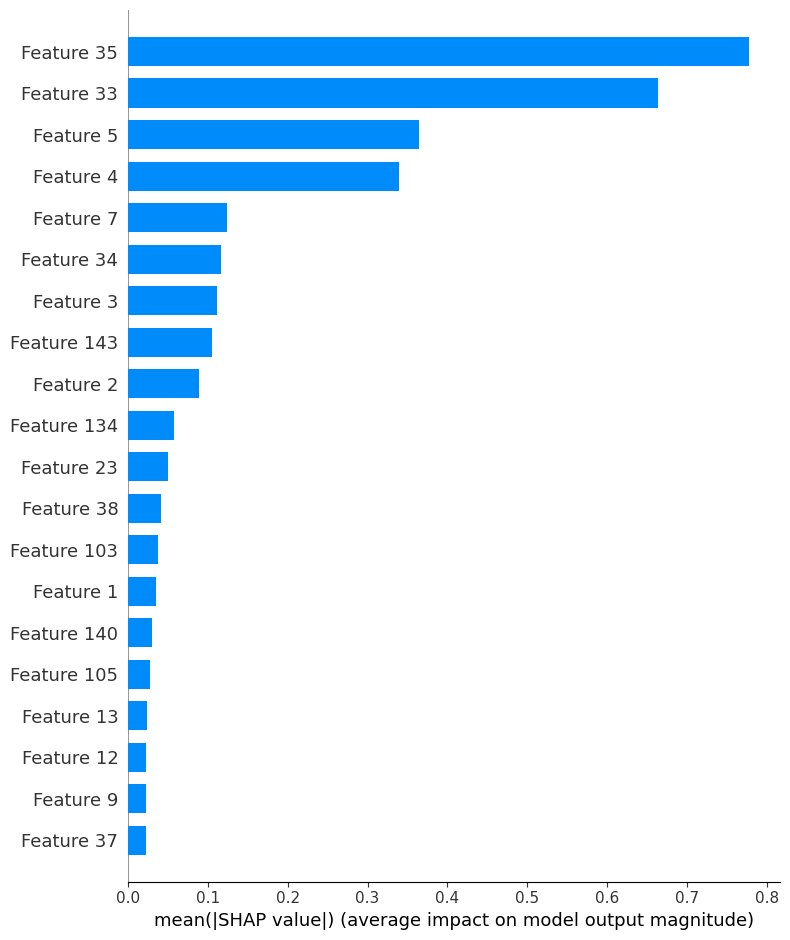

In [81]:
shap.summary_plot(shap_values, X_test_transformed, plot_type="bar", show=False)
plt.savefig('C:/Users/Pratik/DS/credit-risk-ml/reports/figures/summary_global_imp_bar.png', dpi=300)
plt.show()

#### Individual Applicant Explanation

SHAP can also explain individual decisions by decomposing a single prediction
into feature-level contributions.

This enables:
- Transparent credit decisions
- Case-by-case review
- Justification for approvals or rejections

Example-Level Explanation (Individual Applicants)

Below we examine SHAP explanations for individual applicants to understand
*why* the model assigned a particular risk score.

These explanations answer questions such as:
- Which features increased default risk?
- Which features reduced risk?
- What dominated the final decision?

This type of explanation is essential for:
- Manual credit reviews
- Customer-facing explanations
- Regulatory audit trails

In [8]:
example_idx = [0, 5, 10, 25, 50]

example_shap = pd.DataFrame(
    shap_array[example_idx],
    columns=feature_names
)
example_shap['Applicant_Index'] = example_idx

example_shap.to_csv('C:/Users/Pratik/DS/credit-risk-ml/reports/summary_tables/examples_shap.csv')

example_shap

,num__AMT_INCOME_TOTAL,num__AGE_YEARS,num__EMPLOYED_YEARS,num__EXT_SOURCE_1,num__EXT_SOURCE_2,num__EXT_SOURCE_3,num__INCOME_RISK,num__ORG_RISK,cat__NAME_CONTRACT_TYPE_Revolving loans,cat__NAME_EDUCATION_TYPE_Higher education,...,remainder__ANNUITY_INCOME_RATIO,remainder__GOODS_CREDIT_RATIO,remainder__CHILDREN_RATIO,remainder__HAS_CHILDREN,remainder__IS_SINGLE,remainder__HAS_CAR,remainder__HAS_REALTY,remainder__LONG_EMPLOYED,remainder__NAME_EDUCATION_ENC,Applicant_Index
0,-0.000488,0.020868,0.120481,-0.009566,-0.216694,0.193220,0.006809,0.090984,0.006207,-0.046272,...,0.000043,0.000231,0.000114,-0.001239,-0.002871,-0.045077,-0.002522,0.0,-0.205425,0
1,-0.003316,0.039879,0.098083,-0.009566,0.002483,0.571376,0.006809,0.103540,0.006207,0.015424,...,-0.000238,0.001320,0.000114,-0.001239,-0.002871,0.023221,0.006484,0.0,0.070313,5
2,0.000455,0.005911,-0.302624,-0.341918,-0.239519,-0.599919,0.006809,0.103540,0.006207,0.015424,...,0.000134,0.000450,-0.000079,0.000610,-0.002871,0.023221,-0.002522,0.0,0.070313,10
3,-0.001431,0.049977,-0.074823,0.194498,-0.211671,-0.643879,0.006809,0.103540,0.006207,0.015424,...,0.000293,-0.000894,-0.000079,0.000610,-0.002871,-0.045077,-0.002522,0.0,0.070313,25
4,-0.004824,-0.058277,0.020596,-0.009566,-0.302271,-0.310838,-0.031017,-0.168426,-0.035174,0.015424,...,-0.000036,-0.000894,-0.000079,0.000610,-0.002871,0.023221,-0.002522,0.0,0.070313,50


In [9]:
example_shap_long = example_shap.melt(
    id_vars='Applicant_Index',
    var_name='Feature',
    value_name='SHAP_Value'
).sort_values(['Applicant_Index','SHAP_Value'],key=np.abs,ascending=False)

example_shap.to_csv('C:/Users/Pratik/DS/credit-risk-ml/reports/summary_tables/examples_shap_long.csv')

example_shap_long

,Applicant_Index,Feature,SHAP_Value
179,50,remainder__AMT_GOODS_PRICE,0.831577
169,50,remainder__AMT_CREDIT,-0.735859
29,50,num__EXT_SOURCE_3,-0.310838
24,50,num__EXT_SOURCE_2,-0.302271
174,50,remainder__AMT_ANNUITY,-0.175278
...,...,...,...
610,0,remainder__FLAG_DOCUMENT_20,0.000000
615,0,remainder__FLAG_DOCUMENT_21,0.000000
620,0,remainder__AMT_REQ_CREDIT_BUREAU_HOUR,-0.000000
625,0,remainder__AMT_REQ_CREDIT_BUREAU_DAY,0.000000


In [10]:
i = 0

shap.force_plot(
    explainer.expected_value,
    shap_values[i],
    X_test_transformed[i],
    feature_names=feature_names
)

This customer is assessed as higher risk than average, The model prediction is worse than the typical customer mainly due to weak external scores and higher credit amount.

In [11]:
i = 35

shap.force_plot(
    explainer.expected_value,
    shap_values[i],
    X_test_transformed[i],
    feature_names=feature_names
)

This customer is assessed as lower risk than average, The model’s prediction is better than the typical customer, as positive credit signals outweigh the negatives.

#### Connection to Business Decisions

These explanations directly support:
- Risk bucket assignment
- Approval threshold setting
- Manual review workflows
- Regulatory reporting and audits

Explainability bridges the gap between predictive performance
and responsible deployment.